# Validation du modèle — Identification de fragments parallèles

Ce notebook applique les modèles de régression logistique entraînés précédemment à des données comparables non alignées, préalablement converties en CSV par le script `prepare_validation_corpus.py`.

**Prérequis :** avoir exécuté `prepare_validation_corpus.py` qui produit dans `validation/csv/` :
```
validation/csv/
├── fr_gsw_alsacien.csv
├── fr_gsw_mulhousien.csv
├── fr_gsw_strasbourgeois.csv
├── fr_co.csv
└── fr_oc.csv
```

Chaque CSV contient les colonnes : `dialecte`, `langue`, `paire`, `fr_sentence`, `lr_sentence`.

**Pipeline :**
1. Chargement des modèles et des CSV
2. Calcul des variables d'apprentissage
3. Inférence (modèle binaire + multiclasse)
4. Analyse des résultats par dialecte et par langue
5. Export CSV des paires candidates

## 0. Imports et configuration

In [ ]:
!pip install jellyfish

import os
import re
import unicodedata
import string
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import jellyfish

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
CSV_DIR          = "validation/csv/"
MODEL_BIN_PATH   = "logreg_binary.joblib"
MODEL_MC_PATH    = "logreg_multiclass.joblib"
SCALER_PATH      = "scaler.joblib"
SBERT_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
OUTPUT_CSV       = "validation_candidates.csv"

# Minimal confidence to keep a candidate pair
CONFIDENCE_THRESHOLD = 0.75

# To limit CSV files to load (here we don't limit)
CSV_FILES = None

FEATURE_COLS = [
    "sbert_score",
    "length_score",
    "jaccard_bigrams",
    "jaccard_trigrams",
    "jaccard_quadrigrams",
    "phonetic_jaccard",
]



---


## Chargement des modèles

In [ ]:
scaler    = joblib.load(SCALER_PATH)
model_bin = joblib.load(MODEL_BIN_PATH)
model_mc  = joblib.load(MODEL_MC_PATH)
mc_classes = model_mc.classes_

print(f"Scaler            : {SCALER_PATH}")
print(f"Binary model      : {MODEL_BIN_PATH}")
print(f"Multiclass model  : {MODEL_MC_PATH}")

sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
print(f"  SBERT            : {SBERT_MODEL_NAME}")

Scaler            : scaler.joblib
Binary model      : logreg_binary.joblib
Multiclass model  : logreg_multiclass.joblib


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  SBERT            : paraphrase-multilingual-MiniLM-L12-v2


## 2. Chargement des CSV de validation

In [ ]:
def load_validation_csvs(csv_dir: str, files: list = None) -> pd.DataFrame:
    """
    loads all present CSVs in csv_dir (or only those listed in files).
    Returns a dataframe.
    Checks if the needed columns are present and signals missing files.
    """
    expected_cols = {"dialecte", "langue", "paire", "fr_sentence", "lr_sentence"}

    if not os.path.isdir(csv_dir):
        raise FileNotFoundError(
            f"CSV directory not found : {csv_dir}\n"
            f"The validation corpus is probably not present"
        )

    available = sorted(f for f in os.listdir(csv_dir) if f.endswith('.csv'))
    to_load   = files if files else available

    if not to_load:
        raise FileNotFoundError(f"No CSV found in {csv_dir}")

    dfs = []
    for fname in to_load:
        fpath = os.path.join(csv_dir, fname)
        if not os.path.exists(fpath):
            print(f"Missing {fpath} - ignored")
            continue
        df = pd.read_csv(fpath, encoding="utf-8-sig")
        missing = expected_cols - set(df.columns)
        if missing:
            print(f"Error {fname} - missing columns : {missing}")
            continue
        # Deletes lines with empty sentences
        df = df.dropna(subset=["fr_sentence", "lr_sentence"])
        df = df[df["fr_sentence"].str.strip().ne("") & df["lr_sentence"].str.strip().ne("")]
        print(f"  {fname:<35} {len(df):>7} pairs")
        dfs.append(df)

    if not dfs:
        raise ValueError("No valid CSV loaded.")

    return pd.concat(dfs, ignore_index=True)


print("Loading validation CSV files...\n")
df_validation = load_validation_csvs(CSV_DIR, CSV_FILES)

print(f"\nDataFrame         : {len(df_validation)} pairs")
print(f"Present dialects    : {df_validation['dialecte'].unique().tolist()}")
print(f"Present languages   : {df_validation['langue'].unique().tolist()}")

Loading validation CSV files...

  fr_co.csv                              1997 pairs
  fr_gsw_alsacien.csv                  572372 pairs
  fr_gsw_mulhousien.csv                323733 pairs
  fr_gsw_strasbourgeois.csv              2781 pairs
  fr_oc.csv                           1040936 pairs

DataFrame         : 1941819 pairs
Present dialects    : ['fr_co', 'fr_gsw_alsacien', 'fr_gsw_mulhousien', 'fr_gsw_strasbourgeois', 'fr_oc']
Present languages   : ['co', 'gsw', 'oc']


In [ ]:
# Dialectal descriptive statistics
stats = df_validation.groupby("dialecte").agg(
    langue=("langue", "first"),
    paires_totales=("fr_sentence", "count"),
    phrases_fr_uniques=("fr_sentence", "nunique"),
    phrases_lr_uniques=("lr_sentence", "nunique"),
    documents_uniques=("paire", "nunique"),
).reset_index()
print("=== Statistiques par dialecte ===")
print(stats.to_string(index=False))

=== Statistiques par dialecte ===
             dialecte langue  paires_totales  phrases_fr_uniques  phrases_lr_uniques  documents_uniques
                fr_co     co            1997                 734                  13                  5
      fr_gsw_alsacien    gsw          572372               43850                5908                863
    fr_gsw_mulhousien    gsw          323733               19567                4514                298
fr_gsw_strasbourgeois    gsw            2781                 176                  66                  4
                fr_oc     oc         1040936               84077               11801               1590




---


## Calcul des variables d'apprentissage

In [ ]:
def normalize(text: str) -> str:
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return text.translate(str.maketrans("", "", string.punctuation)).strip()

def length_score(s1: str, s2: str) -> float:
    n1, n2 = len(s1.split()), len(s2.split())
    m = max(n1, n2)
    return 0.0 if m == 0 else abs(n1 - n2) / m

def char_ngrams(text: str, n: int) -> set:
    t = normalize(text)
    return set(t[i:i+n] for i in range(len(t) - n + 1))

def jaccard_index(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def jaccard_ngrams(s1: str, s2: str, n: int) -> float:
    return jaccard_index(char_ngrams(s1, n), char_ngrams(s2, n))

def metaphone_codes(text: str) -> set:
    codes = set()
    for word in normalize(text).split():
        try:
            code = jellyfish.metaphone(word)
            if code:
                codes.add(code)
        except Exception:
            pass
    return codes

def phonetic_jaccard(s1: str, s2: str) -> float:
    return jaccard_index(metaphone_codes(s1), metaphone_codes(s2))


def compute_features_batch(fr_sentences: list, lr_sentences: list,
                            sbert_model=None, batch_size: int = 64) -> np.ndarray:
    """
    Calculate the feature vector for a list of pairs.
    Return an array of shape (N, 6).
    """
    n = len(fr_sentences)
    sbert_scores = np.zeros(n)

    if sbert_model is not None:
        for i in tqdm(range(0, n, batch_size), desc="SBERT", leave=False):
            b_fr = fr_sentences[i:i+batch_size]
            b_lr = lr_sentences[i:i+batch_size]
            e_fr = sbert_model.encode(b_fr, convert_to_numpy=True, show_progress_bar=False)
            e_lr = sbert_model.encode(b_lr, convert_to_numpy=True, show_progress_bar=False)
            for j, (v1, v2) in enumerate(zip(e_fr, e_lr)):
                sbert_scores[i+j] = float(max(0.0, cos_sim([v1], [v2])[0][0]))

    rows = []
    for i, (fr, lr) in enumerate(zip(fr_sentences, lr_sentences)):
        rows.append([
            sbert_scores[i],
            length_score(fr, lr),
            jaccard_ngrams(fr, lr, 2),
            jaccard_ngrams(fr, lr, 3),
            jaccard_ngrams(fr, lr, 4),
            phonetic_jaccard(fr, lr),
        ])
    return np.array(rows)

In [ ]:
print(f"Calculating variables for {len(df_validation)} pairs...")

fr_list = df_validation["fr_sentence"].tolist()
lr_list = df_validation["lr_sentence"].tolist()

sbert_arg = sbert_model
features  = compute_features_batch(fr_list, lr_list, sbert_model=sbert_arg)

# Add the variables to the DataFrame
for i, col in enumerate(FEATURE_COLS):
    df_validation[col] = features[:, i]

df_validation[FEATURE_COLS].describe().round(4)

Calculating variables for 1941819 pairs...


SBERT:   0%|          | 0/30341 [00:00<?, ?it/s]

,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
count,1.941819e+06,1.941819e+06,1.941819e+06,1.941819e+06,1.941819e+06,1.941819e+06
mean,1.453000e-01,4.560000e-01,2.123000e-01,5.880000e-02,2.390000e-02,5.770000e-02
std,1.432000e-01,2.450000e-01,8.740000e-02,6.060000e-02,5.190000e-02,6.580000e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.760000e-02,2.500000e-01,1.519000e-01,2.560000e-02,3.300000e-03,1.670000e-02
50%,1.146000e-01,4.667000e-01,2.028000e-01,4.830000e-02,1.380000e-02,4.880000e-02
75%,2.192000e-01,6.579000e-01,2.632000e-01,7.910000e-02,3.100000e-02,8.330000e-02
max,1.000000e+00,9.917000e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00




---


## Inférence

In [ ]:
features_sc  = scaler.transform(features)

# Binary model
pred_bin     = model_bin.predict(features_sc)
proba_bin    = model_bin.predict_proba(features_sc)[:, 1]

# Multiclass model
pred_mc_idx  = model_mc.predict(features_sc)
proba_mc_all = model_mc.predict_proba(features_sc)
conf_mc      = proba_mc_all[np.arange(len(pred_mc_idx)), pred_mc_idx]
label_mc     = [mc_classes[p] for p in pred_mc_idx]

df_validation["pred_binaire"]   = pred_bin
df_validation["confiance_bin"]  = proba_bin.round(4)
df_validation["pred_classe"]    = label_mc
df_validation["confiance_mc"]   = conf_mc.round(4)

print(f"\nDistribution des prédictions binaires :")
print(df_validation["pred_binaire"].value_counts().rename({0: "non-parallèle", 1: "parallèle"}).to_string())
print(f"\nDistribution des classes multiclasse :")
print(df_validation["pred_classe"].value_counts().to_string())


Distribution des prédictions binaires :
pred_binaire
non-parallèle    1657458
parallèle         284361

Distribution des classes multiclasse :
pred_classe
0    1498649
1     231278
2     211892




---


## Analyse des résultats

### Paires candidates

In [ ]:
df_validation.head()

,dialecte,langue,paire,fr_sentence,lr_sentence,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard,pred_binaire,confiance_bin,pred_classe,confiance_mc
0,fr_co,co,Altkirch,Altkirch (prononcé [altkirç] ou [altkirʃ] ; si...,Altkirch hè una cìtta in Alsazia in u Sundgau ...,0.556264,0.675676,0.200000,0.065574,0.028169,0.105263,1,0.7770,2,0.8690
1,fr_co,co,Altkirch,Altkirch (prononcé [altkirç] ou [altkirʃ] ; si...,Hè situata trà Belfort (Territoriu di Belfort ...,0.366403,0.648649,0.139241,0.023256,0.010239,0.024390,0,0.4172,2,0.5385
2,fr_co,co,Altkirch,Altkirch (prononcé [altkirç] ou [altkirʃ] ; si...,"Questa cìttà hè a capitale di u Sundgau, a par...",0.290905,0.648649,0.212329,0.061224,0.010239,0.076923,0,0.3792,0,0.5686
3,fr_co,co,Altkirch,Altkirch (prononcé [altkirç] ou [altkirʃ] ; si...,"Dinù, pudemu traduce Altkirch par ""Vechja chje...",0.527038,0.351351,0.356250,0.097561,0.047478,0.062500,1,0.7990,2,0.6254
4,fr_co,co,Altkirch,Altkirch (prononcé [altkirç] ou [altkirʃ] ; si...,Situ nantu à a cìta di Altkirch Archiviu 2020-...,0.157293,0.324324,0.242424,0.072727,0.030675,0.071429,0,0.3311,0,0.6746


In [ ]:
df_candidates = df_validation[
    (df_validation["pred_binaire"] == 1) &
    (df_validation["confiance_bin"] >= CONFIDENCE_THRESHOLD) &
    (df_validation["sbert_score"] != 1.000) &
    (df_validation["fr_sentence"] != df_validation["lr_sentence"])
].copy().sort_values("confiance_bin", ascending=False)

print(f"Paires candidates retenues (seuil ≥ {CONFIDENCE_THRESHOLD}) :")
print(f"  {len(df_candidates)} / {len(df_validation)} "
      f"({100*len(df_candidates)/max(len(df_validation),1):.1f}%)")

print("\nTop 5 paires candidates :")
for _, row in df_candidates.head(5).iterrows():
    print(f"\n  [{row['dialecte']}] {row['pred_classe']} | "
          f"conf={row['confiance_bin']:.2%} | SBERT={row['sbert_score']:.3f}")
    print(f"  FR : {row['fr_sentence'][:100]}")
    print(f"  LR : {row['lr_sentence'][:100]}")

Paires candidates retenues (seuil ≥ 0.75) :
  99897 / 1941819 (5.1%)

Top 5 paires candidates :

  [fr_oc] 1 | conf=100.00% | SBERT=0.901
  FR : Traubach-le-Haut se situe dans le Sundgau, à 5 km au nord-nord-ouest de Dannemarie.
  LR : Traubach-La-Nautor se situa en lo Sundgau, a unitat|5|km al nòrd-nòrd-oèst de Dannemarie.

  [fr_oc] 1 | conf=100.00% | SBERT=0.646
  FR : Elle constitue le principal monument du village.
  LR : Constituissi lo principal monument del pòble.

  [fr_oc] 1 | conf=100.00% | SBERT=0.958
  FR : La commune prend le nom de Lixing-lès-Rouhling.
  LR : La municipalitat pren lo nom de Lixing-lès-Rouhling.

  [fr_oc] 1 | conf=100.00% | SBERT=0.972
  FR : Situé dans la vallée du Strichbach, la commune est traversée par la RD 910 (Saint-Avold-Sarreguemine
  LR : Situat en la vallée del Strichbach, la municipalitat a traversat per la RD 910 (St-Avold-Sarreguemin

  [fr_oc] 1 | conf=100.00% | SBERT=0.892
  FR : De nombreuses monnaies de Trajan (empereur romain de 98 à 1

### Performances par dialecte et par langue

In [ ]:
def stats_for_group(group_col: str) -> pd.DataFrame:
    """Calculate validation statistics for a group."""
    rows = []
    for val in df_validation[group_col].unique():
        sub  = df_validation[df_validation[group_col] == val]
        cand = sub[
            (sub["pred_binaire"] == 1) &
            (sub["confiance_bin"] >= CONFIDENCE_THRESHOLD) &
            (df_validation["sbert_score"] != 1.000) &
            (df_validation["fr_sentence"] != df_validation["lr_sentence"])
        ]
        par  = cand[cand["pred_classe"] == 1]
        semi = cand[cand["pred_classe"] == 2]
        rows.append({
            group_col:               val,
            "Comparaisons":          len(sub),
            "Candidates":            len(cand),
            "Parallèles":            len(par),
            "Semi-parallèles":       len(semi),
            "Taux extraction (%)": round(100*len(cand)/max(len(sub),1), 2),
            "Conf. moy.": round(cand["confiance_bin"].mean(), 4) if len(cand) else 0,
            "SBERT moy.": round(cand["sbert_score"].mean(), 4)   if len(cand) else 0,
        })
    return pd.DataFrame(rows)


print("=== Par dialecte ===")
stats_dialect = stats_for_group("dialecte")
print(stats_dialect.to_string(index=False))

print("\n=== Par langue ===")
stats_langue = stats_for_group("langue")
print(stats_langue.to_string(index=False))

=== Par dialecte ===
             dialecte  Comparaisons  Candidates  Parallèles  Semi-parallèles  Taux extraction (%)  Conf. moy.  SBERT moy.
                fr_co          1997         124          35               89                 6.21      0.8630      0.5809
      fr_gsw_alsacien        572372       13019        3558             9461                 2.27      0.8590      0.4469
    fr_gsw_mulhousien        323733        8445        2228             6217                 2.61      0.8586      0.4618
fr_gsw_strasbourgeois          2781         114          24               90                 4.10      0.8598      0.5294
                fr_oc       1040936       78195       36300            41895                 7.51      0.8749      0.4752

=== Par langue ===
langue  Comparaisons  Candidates  Parallèles  Semi-parallèles  Taux extraction (%)  Conf. moy.  SBERT moy.
    co          1997         124          35               89                 6.21      0.8630      0.5809
   gsw       

### Visualisations

In [ ]:
df_np = df_candidates[df_candidates["pred_classe"] == 0]

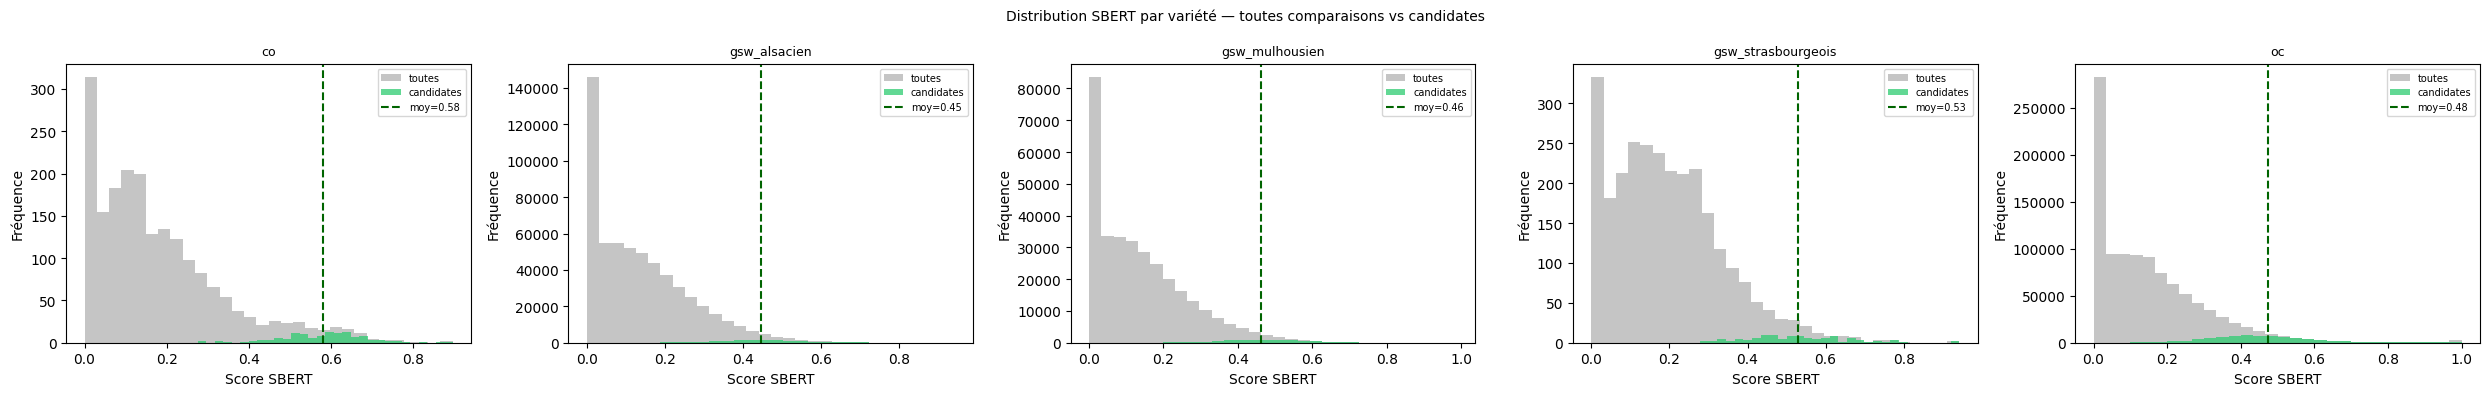

Figure sauvegardée : validation_sbert_par_dialecte.png


In [ ]:
# SBERT distribution: all comparisons vs candidates, by dialect
dialects = df_validation["dialecte"].unique()
n = len(dialects)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=False)
if n == 1:
    axes = [axes]

for ax, var in zip(axes, dialects):
    sub  = df_validation[df_validation["dialecte"] == var]["sbert_score"]
    cand = df_candidates[df_candidates["dialecte"] == var]["sbert_score"]
    ax.hist(sub,  bins=30, alpha=0.45, color="gray", label="toutes")
    ax.hist(cand, bins=30, alpha=0.75, color="#2ecc71",   label="candidates")
    if len(cand):
        ax.axvline(cand.mean(), color="darkgreen", linestyle="--",
                   linewidth=1.5, label=f"moy={cand.mean():.2f}")
    ax.set_title(var.replace("fr_", ""), fontsize=9)
    ax.set_xlabel("Score SBERT")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=7)

plt.suptitle("Distribution SBERT par variété — toutes comparaisons vs candidates",
             fontsize=10)
plt.tight_layout()
plt.savefig("validation_sbert_par_dialecte.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

dialects = df_validation["dialecte"].unique()
n = len(dialects)

fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=False)
if n == 1:
    axes = [axes]

for ax, var in zip(axes, dialects):
    sub  = df_validation[df_validation["dialecte"] == var]["sbert_score"]
    cand = df_candidates[df_candidates["dialecte"] == var]["sbert_score"]

    # KDE for all comparisons
    sns.kdeplot(sub, ax=ax, fill=True, color="gray", alpha=0.4, label="toutes")

    # KDE for all candidates
    if len(cand):
        sns.kdeplot(cand, ax=ax, fill=True, color="#2ecc71", alpha=0.6, label="candidates")

        # Average candidates
        ax.axvline(cand.mean(), color="darkgreen", linestyle="--",
                   linewidth=1.5, label=f"moy={cand.mean():.2f}")

    ax.set_title(var.replace("fr_", ""), fontsize=9)
    ax.set_xlabel("Score SBERT")
    ax.set_ylabel("Densité")
    ax.legend(fontsize=7)

plt.suptitle("Distribution SBERT (KDE) par variété — toutes vs candidates",
             fontsize=10)
plt.tight_layout()
plt.savefig("validation_sbert_par_dialecte_kde.png", dpi=150, bbox_inches="tight")
plt.show()

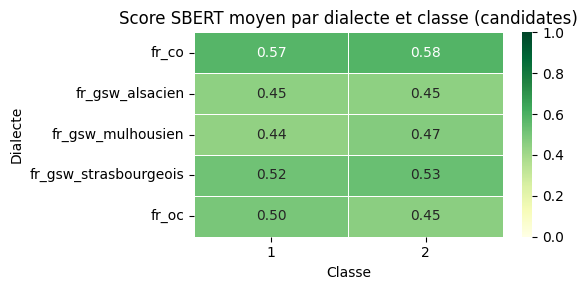

Figure sauvegardée : validation_sbert_heatmap.png


In [ ]:
# Heatmap : SBERT average by dialect and class
if len(df_candidates):
    pivot_heat = (df_candidates
                  .groupby(["dialecte", "pred_classe"])["sbert_score"]
                  .mean()
                  .unstack(fill_value=0))
    fig, ax = plt.subplots(figsize=(6, max(3, len(pivot_heat)*0.6)))
    sns.heatmap(pivot_heat, annot=True, fmt=".2f", cmap="YlGn",
                ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title("Score SBERT moyen par dialecte et classe (candidates)")
    ax.set_xlabel("Classe")
    ax.set_ylabel("Dialecte")
    plt.tight_layout()
    plt.savefig("validation_sbert_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : validation_sbert_heatmap.png")

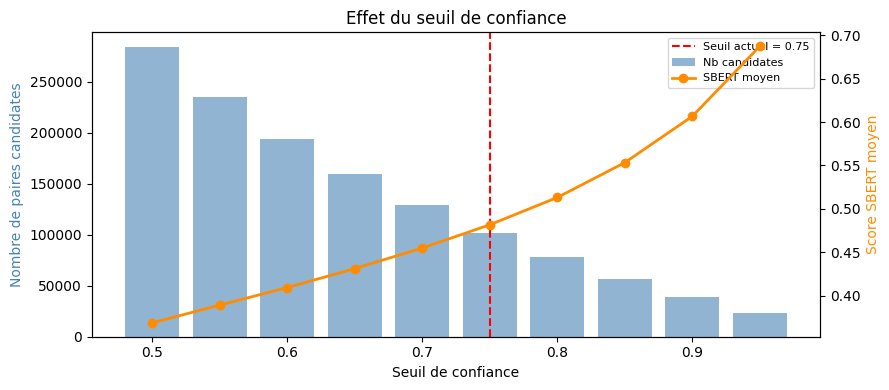

Figure sauvegardée : validation_seuil_confiance.png


In [ ]:
# Effect of the trust threshold on the candidates
thresholds   = np.arange(0.50, 0.96, 0.05)
n_cands_thr  = []
mean_sbert_thr = []

for thr in thresholds:
    c = df_validation[
        (df_validation["pred_binaire"] == 1) &
        (df_validation["confiance_bin"] >= thr)
    ]
    n_cands_thr.append(len(c))
    mean_sbert_thr.append(c["sbert_score"].mean() if len(c) else 0)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(thresholds, n_cands_thr, width=0.04, alpha=0.6,
        color="steelblue", label="Nb candidates")
ax2.plot(thresholds, mean_sbert_thr, 'o-', color="darkorange",
         linewidth=2, label="SBERT moyen")
ax1.axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--",
            linewidth=1.5, label=f"Seuil actuel = {CONFIDENCE_THRESHOLD}")
ax1.set_xlabel("Seuil de confiance")
ax1.set_ylabel("Nombre de paires candidates", color="steelblue")
ax2.set_ylabel("Score SBERT moyen", color="darkorange")
ax1.set_title("Effet du seuil de confiance")
lines = ax1.get_legend_handles_labels()
lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0]+lines2[0], lines[1]+lines2[1], fontsize=8)
plt.tight_layout()
plt.savefig("validation_seuil_confiance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : validation_seuil_confiance.png")



---


## Export CSV

In [ ]:
# Global export
df_candidates.sort_values(
    ["dialecte", "confiance_bin"], ascending=[True, False]
).to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"{OUTPUT_CSV} — {len(df_candidates)} paires")

# Dialectal export
for var in df_candidates["dialecte"].unique():
    sub = df_candidates[df_candidates["dialecte"] == var]
    out = f"validation_candidates_{var}.csv"
    sub.to_csv(out, index=False, encoding="utf-8-sig")
    print(f"{out} — {len(sub)} paires")

validation_candidates.csv — 99897 paires
validation_candidates_fr_oc.csv — 78195 paires
validation_candidates_fr_gsw_alsacien.csv — 13019 paires
validation_candidates_fr_gsw_mulhousien.csv — 8445 paires
validation_candidates_fr_gsw_strasbourgeois.csv — 114 paires
validation_candidates_fr_co.csv — 124 paires




---


## Résumé final

In [ ]:
print("=" * 60)
print("RÉSUMÉ DE LA VALIDATION")
print("=" * 60)
print(f"Seuil de confiance        : {CONFIDENCE_THRESHOLD}")
print(f"Comparaisons totales      : {len(df_validation)}")
print(f"Paires candidates retenues: {len(df_candidates)} "
      f"({100*len(df_candidates)/max(len(df_validation),1):.1f}%)")
print()
print("--- Par dialecte ---")
print(stats_dialect.to_string(index=False))
print()
print("--- Par langue ---")
print(stats_langue.to_string(index=False))

RÉSUMÉ DE LA VALIDATION
Seuil de confiance        : 0.75
Comparaisons totales      : 1941819
Paires candidates retenues: 99897 (5.1%)

--- Par dialecte ---
             dialecte  Comparaisons  Candidates  Parallèles  Semi-parallèles  Taux extraction (%)  Conf. moy.  SBERT moy.
                fr_co          1997         124           0                0                 6.21      0.8630      0.5809
      fr_gsw_alsacien        572372       13019           0                0                 2.27      0.8590      0.4469
    fr_gsw_mulhousien        323733        8445           0                0                 2.61      0.8586      0.4618
fr_gsw_strasbourgeois          2781         114           0                0                 4.10      0.8598      0.5294
                fr_oc       1040936       78195           0                0                 7.51      0.8749      0.4752

--- Par langue ---
langue  Comparaisons  Candidates  Parallèles  Semi-parallèles  Taux extraction (%)  Conf. mo